# Cassini CDA Dust Analyzer: Inspect GCP Plot Style

This notebook loads a random preprocessed spectrum sample from the local dataset and renders it using the exact plotting utility, scaling, and style that are used when submitting payloads to Gemini/GCP.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
from IPython.display import Image, display

# Ensure relative imports work correctly
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from scripts.run_ablation_study_incremental import preprocess_huggingface_data
from cda_dust_agent.tools.utils import generate_spectrum_image_bytes

In [21]:
# Load the dataset preprocessed with DataFetchAndParseAgent
df = preprocess_huggingface_data("both")

# Randomly sample a row
random_row = df.loc[df["class"]=="2"].sample(n=1).iloc[0]

print(f"Sampled SCLK ID: {random_row['sclk']}")
print(f"Ground Truth Class: {random_row['class']}")

Sampled SCLK ID: 1489096441
Ground Truth Class: 2


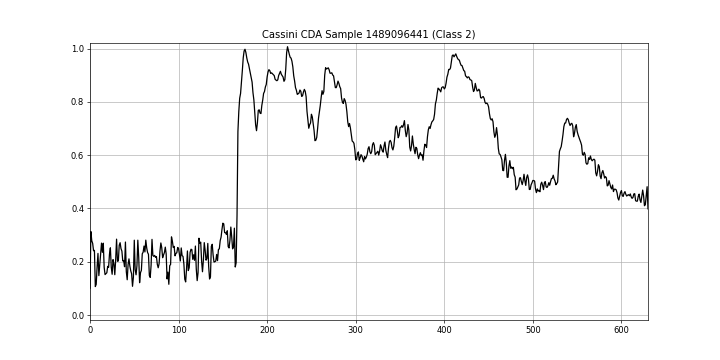

In [22]:
# Render the spectrum plot
# The layout uses 12x6 inches, grid lines, and linear plot styling of log-preprocessed values
img_bytes = generate_spectrum_image_bytes(
    random_row['spectrum'], 
    title=f"Cassini CDA Sample {random_row['sclk']} (Class {random_row['class']})",
    dpi=60
)

# Display inside the notebook
display(Image(data=img_bytes))